# Assignment 2: Titanic Data Wrangling and Exploratory Analysis

**Dataset:** Titanic  
**Source:** Seaborn sample-data repository  
**Source URL:** https://github.com/mwaskom/seaborn-data/blob/master/titanic.csv  
**License:** BSD 3-Clause  

I chose this dataset because it contains numeric and categorical variables,
has missing values that require deliberate cleaning, and can be used to
investigate how passenger characteristics were related to survival.

In [6]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

DATA_PATH = Path("../data/raw/titanic.csv")
REPORTS_DIR = Path("../reports")
PROCESSED_DIR = Path("../data/processed")

REPORTS_DIR.mkdir(exist_ok=True)
PROCESSED_DIR.mkdir(exist_ok=True)

df = pd.read_csv(DATA_PATH)

In [7]:
print("Dataset shape:")
print(df.shape)

print("\nColumn names:")
print(df.columns.tolist())

print("\nData types:")
print(df.dtypes)

print("\nMissing values:")
print(df.isna().sum())

print("\nUnique values, including missing values:")
print(df.nunique(dropna=False))

print("\nExact duplicate rows:")
print(df.duplicated().sum())

Dataset shape:
(891, 15)

Column names:
['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare', 'embarked', 'class', 'who', 'adult_male', 'deck', 'embark_town', 'alive', 'alone']

Data types:
survived         int64
pclass           int64
sex                str
age            float64
sibsp            int64
parch            int64
fare           float64
embarked           str
class              str
who                str
adult_male        bool
deck               str
embark_town        str
alive              str
alone             bool
dtype: object

Missing values:
survived         0
pclass           0
sex              0
age            177
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64

Unique values, including missing values:
survived         2
pclass           3
sex              2
age             89
sibsp    

In [8]:
clean_df = df.copy()

In [9]:
#calculate age medians between passenger groups
group_age_medians = clean_df.groupby(
    ["pclass", "sex"]
)["age"].transform("median")

clean_df["age"] = clean_df["age"].fillna(group_age_medians)

In [10]:
#for the missing columns in the embarked column, we will fill them with the most common value, which is 'S'
clean_df["embarked"] = clean_df["embarked"].fillna(
    clean_df["embarked"].mode().iloc[0]
)

clean_df["embark_town"] = clean_df["embark_town"].fillna(
    clean_df["embark_town"].mode().iloc[0]
)


In [11]:
#flag missing deck rows, I choose to flag them instead of removing them because they are many and that will affect the dataset
clean_df["deck"] = clean_df["deck"].fillna("Unknown")


In [12]:
#using panda to convert column names to pandas cateogory data type, this will help with memory usage and also make it easier to work with the data
categorical_columns = [
    "sex",
    "embarked",
    "class",
    "who",
    "deck",
    "embark_town",
]

for column in categorical_columns:
    clean_df[column] = clean_df[column].astype("category")

In [13]:
#REtaining duplicate records as we might intefere with the data if we remove them
duplicate_count = clean_df.duplicated().sum()

print("Duplicate-looking rows retained:", duplicate_count)

Duplicate-looking rows retained: 113


In [14]:
#verify that the data has been cleaned and processed
print(clean_df.isna().sum())
print(clean_df.dtypes)
print(clean_df.shape)

survived       0
pclass         0
sex            0
age            0
sibsp          0
parch          0
fare           0
embarked       0
class          0
who            0
adult_male     0
deck           0
embark_town    0
alive          0
alone          0
dtype: int64
survived          int64
pclass            int64
sex            category
age             float64
sibsp             int64
parch             int64
fare            float64
embarked       category
class          category
who            category
adult_male         bool
deck           category
embark_town    category
alive               str
alone              bool
dtype: object
(891, 15)


In [15]:
#How did passenger sex and class relate to survival, age, and fares?
print("Shape before groupby and merge:", clean_df.shape)

group_stats = (
    clean_df.groupby(["sex", "class"], observed=True)
    .agg(
        group_survival_rate=("survived", "mean"),
        group_mean_fare=("fare", "mean"),
        group_median_age=("age", "median"),
        group_passenger_count=("survived", "size"),
    )
    .reset_index()
)

group_stats

clean_df = clean_df.merge(
    group_stats,
    on=["sex", "class"],
    how="left",
    validate="many_to_one",
)

print("Shape after groupby and merge:", clean_df.shape)



Shape before groupby and merge: (891, 15)
Shape after groupby and merge: (891, 19)


In [16]:
#printing the shape before and after,places male and female survival rates side by side,
# making class-based differences easier to compare.

print("Shape before pivot:", group_stats.shape)

survival_pivot = group_stats.pivot(
    index="class",
    columns="sex",
    values="group_survival_rate",
)

print("Shape after pivot:", survival_pivot.shape)
survival_pivot


Shape before pivot: (6, 6)
Shape after pivot: (3, 2)


sex,female,male
class,,
First,0.968085,0.368852
Second,0.921053,0.157407
Third,0.500000,0.135447


In [17]:
#log trasformation of the fare column to reduce skewness and make it more normally distributed
fare_array = clean_df["fare"].to_numpy(dtype=float)

log_fare = np.log1p(fare_array)

log_fare_zscore = (
    log_fare - log_fare.mean()
) / log_fare.std(ddof=0)

print("Mean:", log_fare_zscore.mean())
print("Standard deviation:", log_fare_zscore.std(ddof=0))
print("Minimum:", log_fare_zscore.min())
print("Maximum:", log_fare_zscore.max())

clean_df["log_fare_zscore"] = log_fare_zscore


Mean: -1.7145531783212295e-16
Standard deviation: 0.9999999999999999
Minimum: -3.0585777291682934
Maximum: 3.3852937438182273


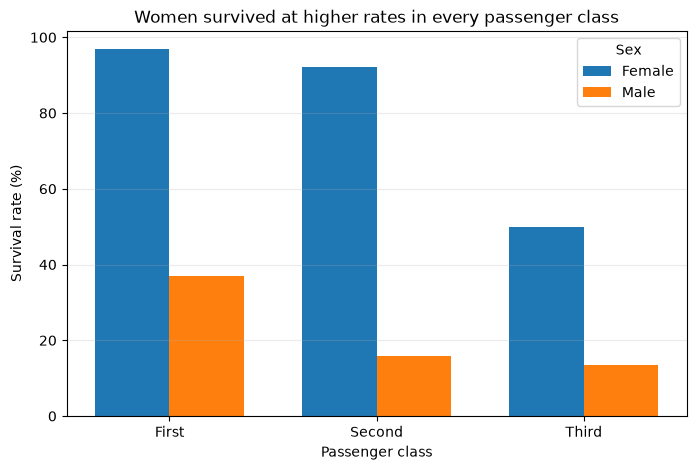

In [18]:
#vhart for survival rates by sex and class
class_order = ["First", "Second", "Third"]
chart1_data = survival_pivot.reindex(class_order)

x = np.arange(len(class_order))
width = 0.36

fig, ax = plt.subplots(figsize=(8, 5))

ax.bar(
    x - width / 2,
    chart1_data["female"] * 100,
    width,
    label="Female",
)

ax.bar(
    x + width / 2,
    chart1_data["male"] * 100,
    width,
    label="Male",
)

ax.set_xticks(x, class_order)
ax.set_xlabel("Passenger class")
ax.set_ylabel("Survival rate (%)")
ax.set_title("Women survived at higher rates in every passenger class")
ax.legend(title="Sex")
ax.grid(axis="y", alpha=0.25)

plt.savefig(
    REPORTS_DIR / "a2_chart1.png",
    dpi=150,
    bbox_inches="tight",
)

plt.show()


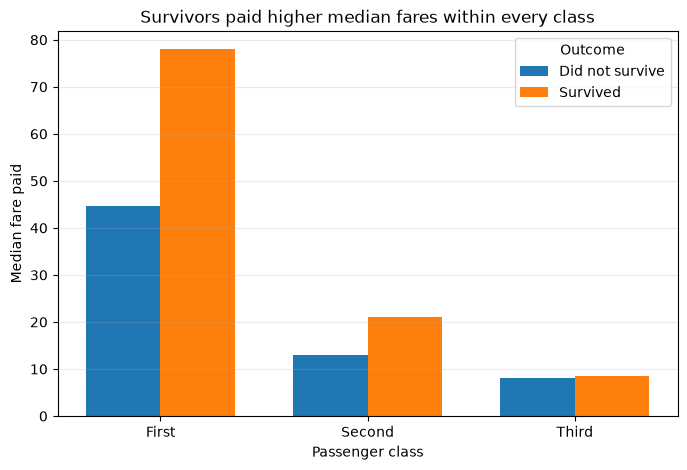

In [20]:
#chart to compare meridian fares for survivors and non-survivors within each class

fare_summary = (
    clean_df.groupby(
        ["class", "survived"],
        observed=True,
    )["fare"]
    .median()
    .unstack("survived")
    .reindex(class_order)
)

fare_summary


x = np.arange(len(class_order))
width = 0.36

fig, ax = plt.subplots(figsize=(8, 5))

ax.bar(
    x - width / 2,
    fare_summary[0],
    width,
    label="Did not survive",
)

ax.bar(
    x + width / 2,
    fare_summary[1],
    width,
    label="Survived",
)

ax.set_xticks(x, class_order)
ax.set_xlabel("Passenger class")
ax.set_ylabel("Median fare paid")
ax.set_title("Survivors paid higher median fares within every class")
ax.legend(title="Outcome")
ax.grid(axis="y", alpha=0.25)

plt.savefig(
    REPORTS_DIR / "a2_chart2.png",
    dpi=150,
    bbox_inches="tight",
)

plt.show()

In [21]:
#saving th processed data to a new CSV file
OUTPUT_PATH = PROCESSED_DIR / "titanic_cleaned.csv"

clean_df.to_csv(OUTPUT_PATH, index=False)

print("Saved to:", OUTPUT_PATH)
print("Final shape:", clean_df.shape)
print("Remaining missing values:", clean_df.isna().sum().sum())

Saved to: ../data/processed/titanic_cleaned.csv
Final shape: (891, 20)
Remaining missing values: 0
